In [20]:
import pandas as pd

df = pd.read_csv("../data/online_retail_II.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [22]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [ ]:
#Conversion de fechas
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

#Cancelaciones
cancelaciones = df[df['Invoice'].str.startswith('C')]
print(f"Cancelaciones: {len(cancelaciones)}")

#Cantidades y precios extraños
print(f"Cantidad <= 0: {(df['Quantity'] <= 0).sum()}")
print(f"Precio <= 0: {(df['Price'] <= 0).sum()}")

#Duplicados exactos
print(f"Filas duplicadas: {df.duplicated().sum()}")

Cancelaciones: 19494
Cantidad <= 0: 22950
Precio <= 0: 6207
Filas duplicadas: 34335


In [24]:
# Cantidad <= 0 que NO son cancelaciones formales
raras = df[(df['Quantity'] <= 0) & (~df['Invoice'].str.startswith('C'))]
print(raras[['Invoice', 'StockCode', 'Description', 'Quantity']].head(10))

# Qué códigos tienen los precios <= 0
print(df[df['Price'] <= 0]['StockCode'].value_counts().head(10))

     Invoice StockCode      Description  Quantity
263   489464     21733     85123a mixed       -96
283   489463     71477            short      -240
284   489467    85123A      21733 mixed      -192
470   489521     21646              NaN       -50
3114  489655     20683              NaN       -44
3162  489660     35956             lost     -1043
3168  489663    35605A          damages      -117
4296  489806     18010              NaN      -770
4538  489820     21133  invcd as 84879?      -720
4566  489821    85049G              NaN      -240
StockCode
46000M    18
22501     18
79321     17
21116     16
22423     16
23084     16
46000S    15
22734     15
22139     14
35965     14
Name: count, dtype: int64


In [25]:
"""
Pipeline de limpieza para el dataset Online Retail II.

Elimina pedidos cancelados, transacciones inválidas y registros
duplicados para dejar el dataset listo para el análisis exploratorio.
"""

# Se trabaja sobre una copia para conservar el dataframe original sin modificar
df_clean = df.copy()

# Se eliminan las cancelaciones (facturas que inician con 'C')
df_clean = df_clean[~df_clean['Invoice'].str.startswith('C')]

# Se eliminan cantidades no positivas que no quedaron marcadas como cancelación
df_clean = df_clean[df_clean['Quantity'] > 0]

# Se eliminan precios no positivos: corresponden a códigos de ajuste
# (ej. POST = envío, D = descuento, M = ajuste manual), no a productos reales
df_clean = df_clean[df_clean['Price'] > 0]

# Se eliminan filas duplicadas exactas
df_clean = df_clean.drop_duplicates()

# Resumen del impacto de la limpieza
filas_eliminadas = len(df) - len(df_clean)
print(f"Filas originales: {len(df):,}")
print(f"Filas después de limpiar: {len(df_clean):,}")
print(f"Eliminadas: {filas_eliminadas:,} ({filas_eliminadas/len(df)*100:.1f}%)")

Filas originales: 1,067,371
Filas después de limpiar: 1,007,913
Eliminadas: 59,458 (5.6%)


In [27]:
# Ingreso por línea = cantidad x precio unitario
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']

print(f"Ingreso total: £{df_clean['Revenue'].sum():,.2f}")

Ingreso total: £20,476,260.45


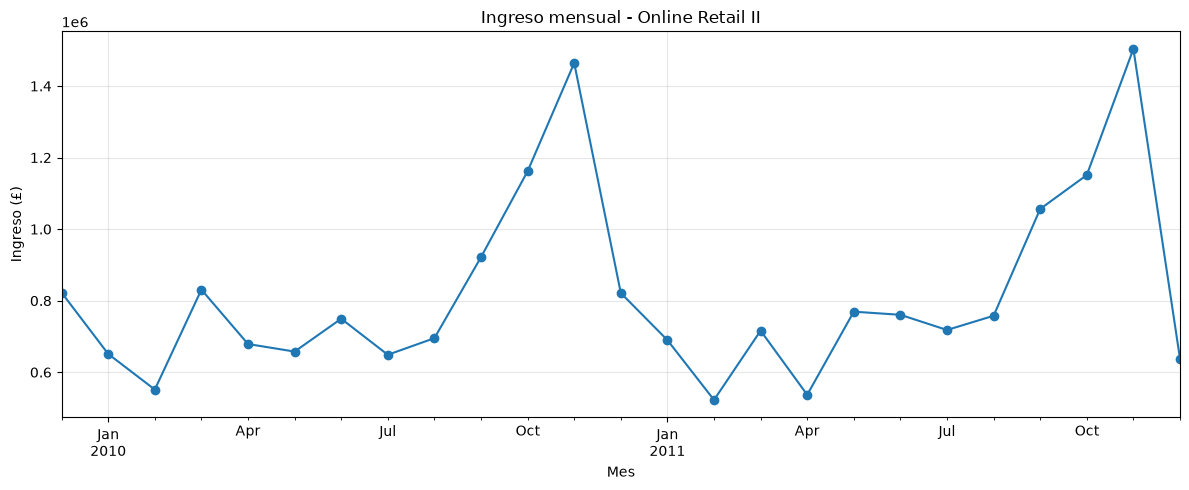

In [29]:
import matplotlib.pyplot as plt

# Agrupa el ingreso por mes usando la fecha de factura
monthly_revenue = df_clean.set_index('InvoiceDate').resample('ME')['Revenue'].sum()

plt.figure(figsize=(12, 5))
monthly_revenue.plot(kind='line', marker='o')
plt.title('Ingreso mensual - Online Retail II')
plt.xlabel('Mes')
plt.ylabel('Ingreso (£)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Description
Manual                                339241.29
REGENCY CAKESTAND 3 TIER              330590.32
DOTCOM POSTAGE                        309854.11
WHITE HANGING HEART T-LIGHT HOLDER    260990.22
PAPER CRAFT , LITTLE BIRDIE           168469.60
PARTY BUNTING                         148318.28
JUMBO BAG RED RETROSPOT               148073.47
ASSORTED COLOUR BIRD ORNAMENT         129324.49
POSTAGE                               125682.42
PAPER CHAIN KIT 50'S CHRISTMAS        117760.29
Name: Revenue, dtype: float64
Country
EIRE           658767.310
Netherlands    554038.090
Germany        425019.711
France         350456.090
Australia      169283.460
Spain          108332.490
Switzerland    100685.590
Sweden          91869.820
Denmark         68580.690
Belgium         65387.820
Name: Revenue, dtype: float64


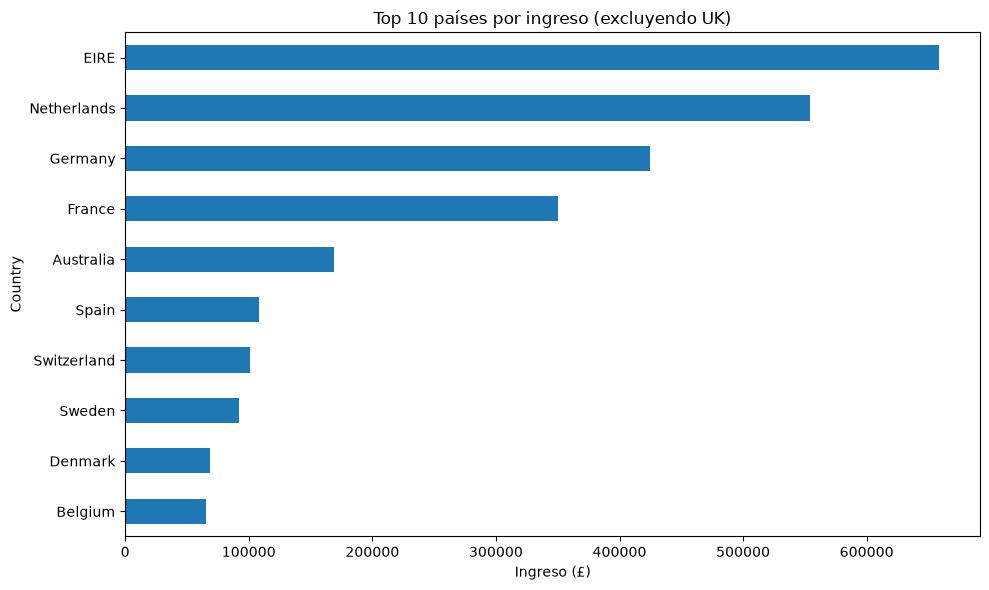

In [30]:
# Top 10 productos por ingreso
top_products = df_clean.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
print(top_products)

# Top 10 países por ingreso, excluyendo Reino Unido
# (UK domina tanto que tapa el resto — vale más verlo aparte)
top_countries_intl = (df_clean[df_clean['Country'] != 'United Kingdom']
                       .groupby('Country')['Revenue'].sum()
                       .sort_values(ascending=False).head(10))
print(top_countries_intl)

# Gráfico de barras horizontal
plt.figure(figsize=(10, 6))
top_countries_intl.sort_values().plot(kind='barh')
plt.title('Top 10 países por ingreso (excluyendo UK)')
plt.xlabel('Ingreso (£)')
plt.tight_layout()
plt.show()

In [31]:
# Códigos especiales conocidos de este dataset (no son productos, son ajustes/envíos)
codigos_especiales = ['POST', 'DOT', 'M', 'C2', 'BANK CHARGES', 'PADS', 'AMAZONFEE']
df_products = df_clean[~df_clean['StockCode'].isin(codigos_especiales)]

top_products_real = df_products.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
print(top_products_real)

Description
REGENCY CAKESTAND 3 TIER               330590.32
WHITE HANGING HEART T-LIGHT HOLDER     260990.22
PAPER CRAFT , LITTLE BIRDIE            168469.60
PARTY BUNTING                          148318.28
JUMBO BAG RED RETROSPOT                148073.47
ASSORTED COLOUR BIRD ORNAMENT          129324.49
PAPER CHAIN KIT 50'S CHRISTMAS         117760.29
MEDIUM CERAMIC TOP STORAGE JAR          81700.92
CHILLI LIGHTS                           80540.88
ROTATING SILVER ANGELS T-LIGHT HLDR     71300.40
Name: Revenue, dtype: float64
